In [1]:
import numpy
from astropy.table import Table
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import s3fs
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from astropy.coordinates import SkyCoord 
import astropy.units as u
from astropy.nddata import Cutout2D
from astropy.time import Time
import warnings
from astropy.wcs import FITSFixedWarning
from upath import UPath
import lsdb
import os

print('Imported Libraries')

Imported Libraries


In [2]:
def is_valid_image(data, threshold=0.05):
    """
    Determines whether the input image data is valid based on the fraction of non-NaN pixels.

    Parameters:
        data (np.ndarray): The image data array.
        threshold (float): Minimum fraction of valid (non-NaN) pixels required to consider the image valid.

    Returns:
        bool: True if the image is valid, False otherwise.
    """
    if data is None:
        return False

    if not isinstance(data, np.ndarray):
        return False

    total_pixels = data.size
    if total_pixels == 0:
        return False

    valid_pixels = np.count_nonzero(np.isfinite(data))
    valid_fraction = valid_pixels / total_pixels

    return valid_fraction >= threshold

def truncate(x):
    if pd.isna(x) or np.isnan(x): return x
    return int(x * 1000) / 1000


In [20]:
filenames_i = ['rings.v3.skycell.2327.023.wrp.i.56793_44472.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56759_55227.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.55340_33927.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56404_53091.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.56793_41894.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55696_43322.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.55339_34326.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55677_55975.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.56028_54785.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55677_56475.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.56759_51277.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56045_50100.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.56759_53910.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56045_51238.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.56759_52591.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56404_52012.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.56404_53025.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55340_33110.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.56380_59718.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55677_54784.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.54985_42884.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56028_55843.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.55340_32698.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55677_54322.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.56404_51905.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56380_60782.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.56793_45765.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55340_31819.combined.fits', 
             'rings.v3.skycell.2327.023.wrp.i.56793_43183.combined.fits']

filenames_g = ['rings.v3.skycell.2327.023.wrp.g.55681_57279.combined.fits', 'rings.v3.skycell.2327.023.wrp.g.55334_37545.combined.fits', 
               'rings.v3.skycell.2327.023.wrp.g.55674_38185.combined.fits', 'rings.v3.skycell.2327.023.wrp.g.56394_59013.combined.fits', 
               'rings.v3.skycell.2327.023.wrp.g.55334_39578.combined.fits', 'rings.v3.skycell.2327.023.wrp.g.56037_46855.combined.fits', 
               'rings.v3.skycell.2327.023.wrp.g.55681_55757.combined.fits', 'rings.v3.skycell.2327.023.wrp.g.55681_55314.combined.fits', 
               'rings.v3.skycell.2327.023.wrp.g.56042_54481.combined.fits', 'rings.v3.skycell.2327.023.wrp.g.55674_39262.combined.fits', 
               'rings.v3.skycell.2327.023.wrp.g.56394_59076.combined.fits', 'rings.v3.skycell.2327.023.wrp.g.55334_38333.combined.fits', 
               'rings.v3.skycell.2327.023.wrp.g.56394_58036.combined.fits', 'rings.v3.skycell.2327.023.wrp.g.56389_55794.combined.fits', 
               'rings.v3.skycell.2327.023.wrp.g.56394_57932.combined.fits', 'rings.v3.skycell.2327.023.wrp.g.56037_47910.combined.fits', 
               'rings.v3.skycell.2327.023.wrp.g.55334_38745.combined.fits', 'rings.v3.skycell.2327.023.wrp.g.56389_56852.combined.fits',
               'rings.v3.skycell.2327.023.wrp.g.56042_53402.combined.fits']

In [ ]:
def plot_imgs_with_gaia_vec(band, ra, dec, pm_ra, pm_dec, mag, source_id):

    # Step 1: Extract dates and headers
    date_index_list = []
    for (roots,dirs,files) in os.walk('./kbmod_fits_examples/i_band/'):
        for i in range(len(files)):
            print(f"Roots:{roots}\nDirs:{dirs}\nFiles:{files}\n")
            file=files[i]
            file_path = Path(roots +'/'+ file)
            print(file_path)
            with fits.open(file_path.open('rb')) as hdul:
                hdr = hdul[1].header
            obs_date_mjd = hdr['MJD-OBS']
            date_index_list.append((obs_date_mjd, i, hdr))  # Save header

    # Step 2: Sort by date
    date_index_list.sort()

    target_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame='icrs')

    # Pre-filter images to find valid ones
    valid_images = []
    for date_obj, original_idx, hdr in date_index_list:
        filename = filenames_i[original_idx]
        file_path = Path('./kbmod_fits_examples/i_band/' + filename)

        with fits.open(file_path.open('rb')) as hdul:
            hdr = hdul[1].header
            image = hdul[1].data

        with warnings.catch_warnings():
            warnings.simplefilter('ignore', FITSFixedWarning)
            wcs = WCS(hdr)

        try:
            cutout = Cutout2D(image, target_coord, 150 * u.arcsec, wcs=wcs)
        except Exception as e:
            continue  # Skip if Cutout2D fails (e.g. star near image edge)

        if not is_valid_image(cutout.data, threshold=0.05):
            continue  # Skip if mostly NaNs

        valid_images.append((cutout, hdr, date_obj))

    if len(valid_images) < 1:
        print("No valid images to display.")
        return

    # Step 3: Prepare figure
    num_valid = len(valid_images)
    cols = int(np.ceil(np.sqrt(num_valid)))
    rows = int(np.ceil(num_valid / cols))

    fig = plt.figure(figsize=(20, 18))
    fig.suptitle(f"Pan-STARRS High PM Star Images, {band} band\n RA:{truncate(ra)}, DEC:{truncate(dec)}, Gaia-Mag:{truncate(mag)}", 
                 fontsize=28, y=0.96)

    for plot_idx, (cutout, hdr, date_obj) in enumerate(valid_images):
        ax = fig.add_subplot(rows, cols, plot_idx + 1, projection=cutout.wcs)
        im = ax.imshow(cutout.data, origin='lower', vmin=0, vmax=20)
        ax.set_xlabel('DEC')
        ax.set_ylabel('RA', labelpad=-1)

        obs_date = str(Time(date_obj, format='mjd').to_datetime()).split(' ')[0]
        ax.set_title(f'Date: {obs_date}', fontsize=16)
        fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.8)

        # # Gaia Vector
        # pm_ra_cosdec = pm_ra / np.cos(np.radians(dec))
        # coord = SkyCoord(ra=ra * u.deg,
        #                  dec=dec * u.deg,
        #                  pm_ra_cosdec=pm_ra_cosdec * u.mas/u.yr,
        #                  pm_dec=pm_dec * u.mas/u.yr, obstime='J2010')
        # new_coord = coord.apply_space_motion(new_obstime=Time('J2013'))

        # end_vec = skycoord_to_pixel(new_coord, cutout.wcs)
        # origin = skycoord_to_pixel(coord, cutout.wcs)
        # vec = np.array(end_vec) - np.array(origin)
        # ax.quiver(*origin, *vec, angles='xy', scale_units='xy', scale=1, color='red', zorder=10)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

Roots:./kbmod_fits_examples/i_band/
Dirs:[]
Files:['rings.v3.skycell.2327.023.wrp.i.56793_44472.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56759_55227.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55340_33927.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56404_53091.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56793_41894.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55696_43322.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55339_34326.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55677_55975.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56028_54785.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.55677_56475.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56759_51277.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56045_50100.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56759_53910.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56045_51238.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.56759_52591.combined.fits', 'rings.v3.skycell.2327.023.wrp.i.5

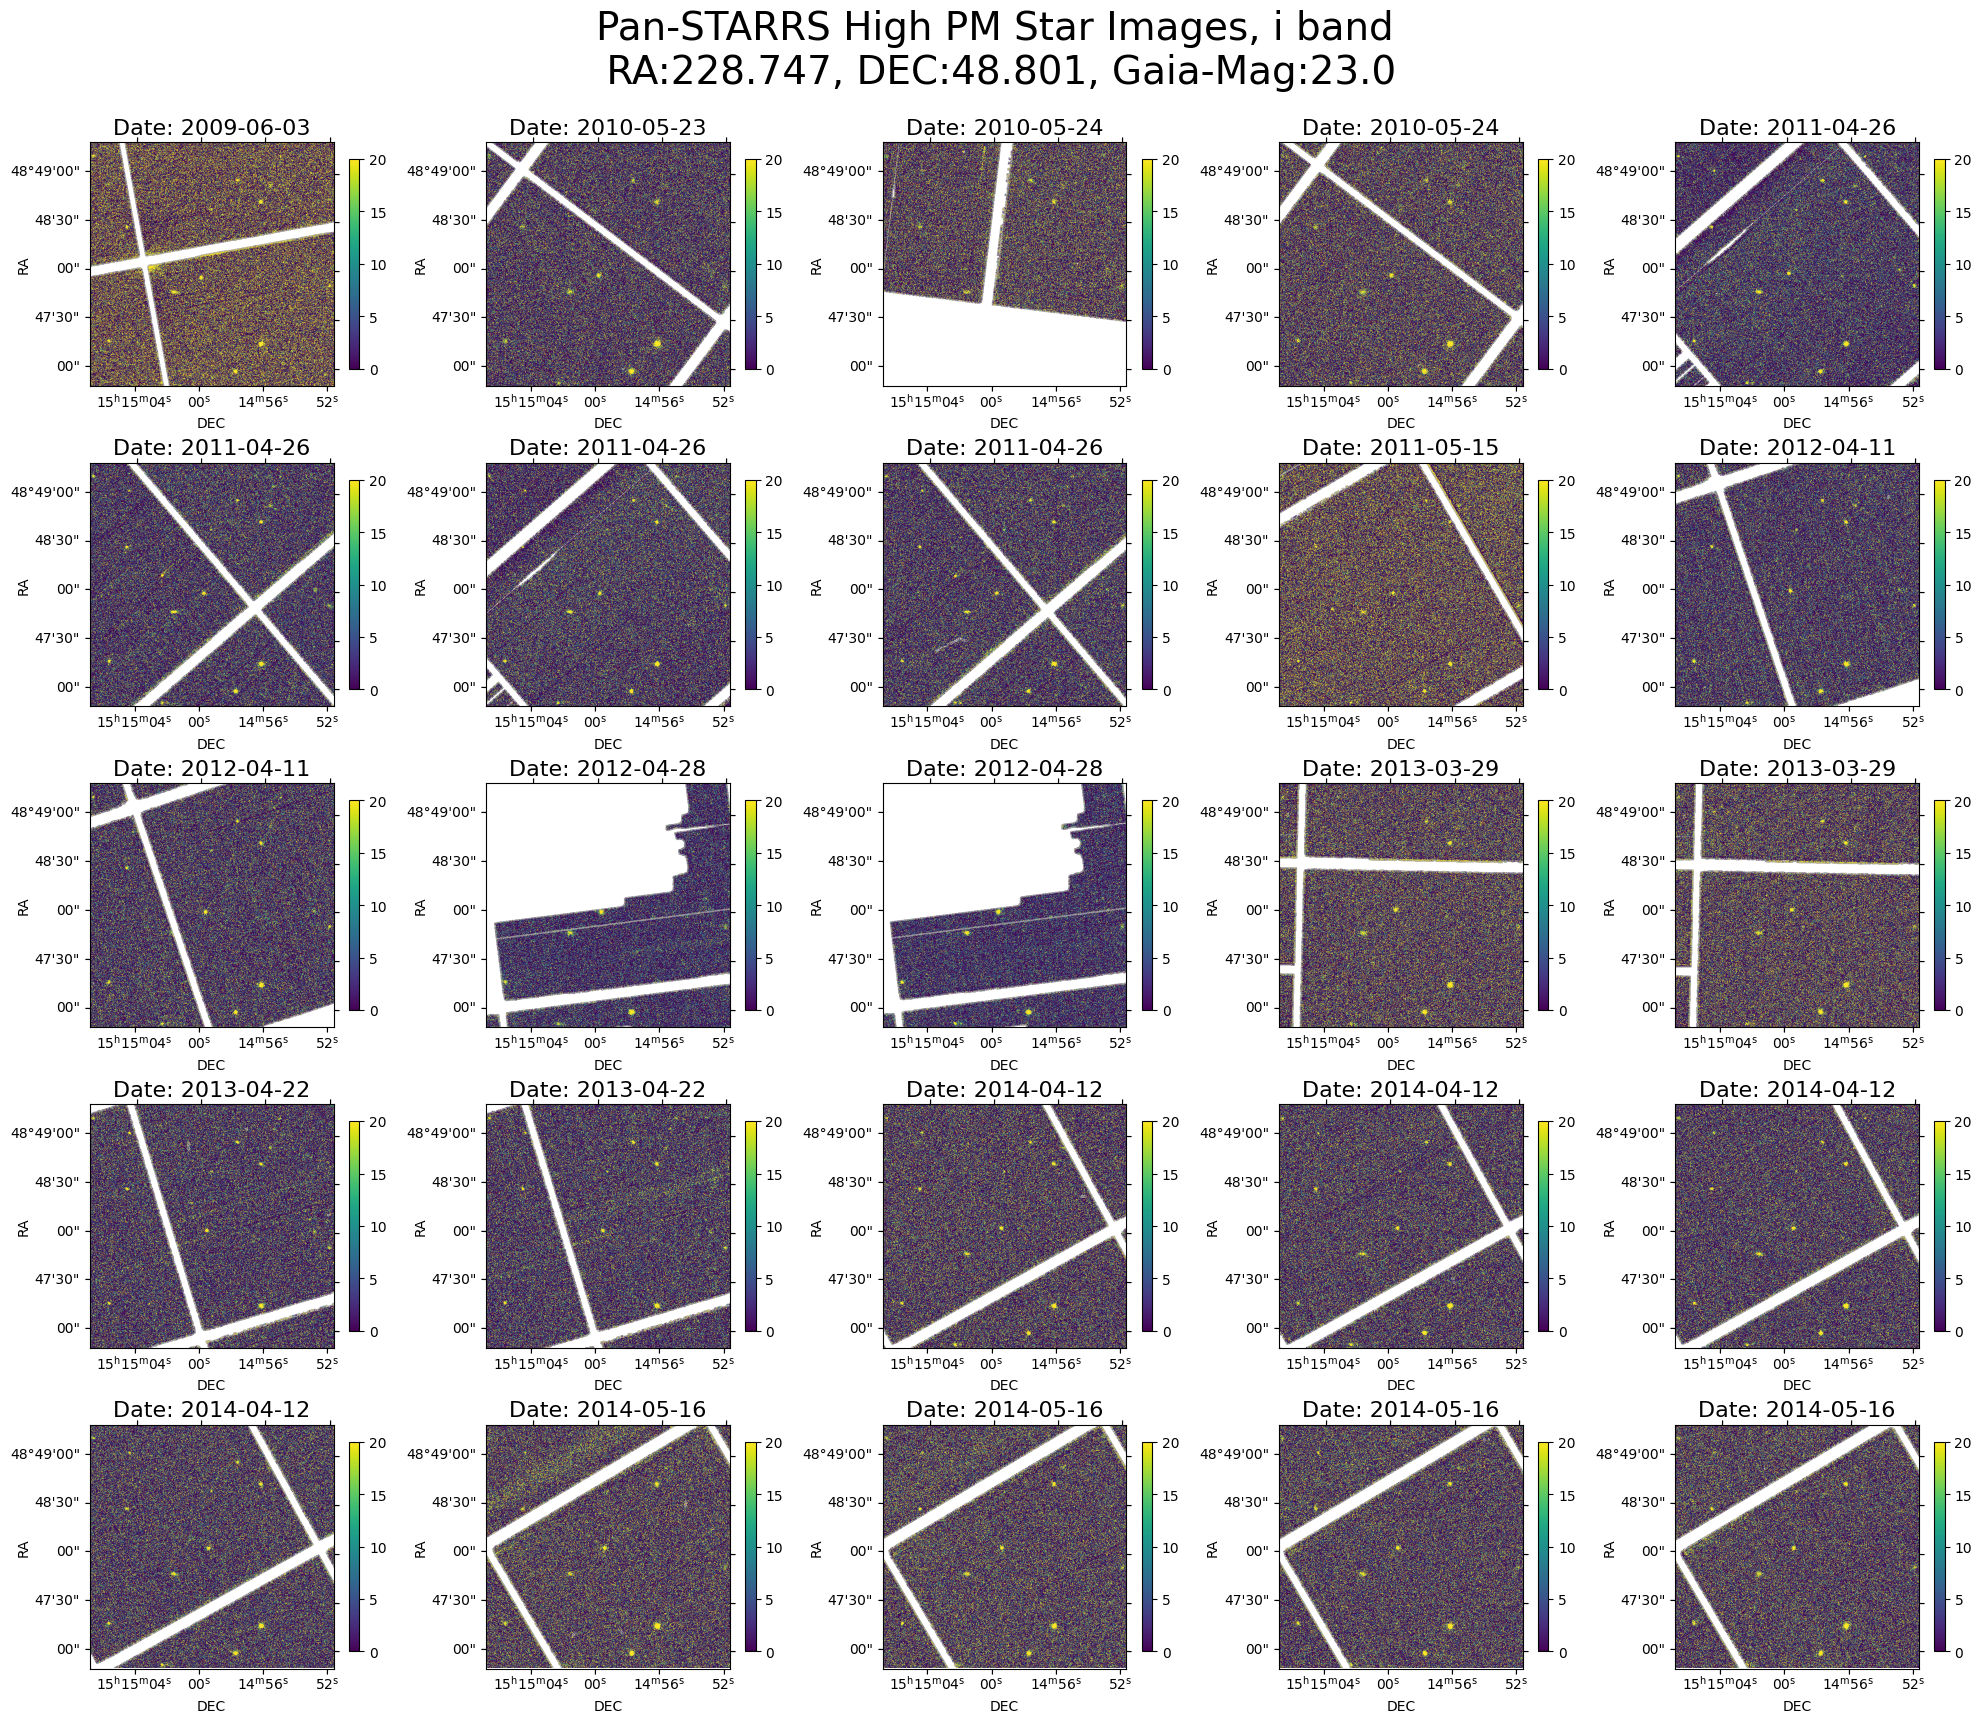

In [35]:
plot_imgs_with_gaia_vec('i', 228.747, 48.801, 20, 20, 23, 20)

In [38]:
with fits.open(Path("./kbmod_fits_examples/g_band/rings.v3.skycell.2327.023.wrp.g.55681_57279.combined.fits").open('rb')) as hdul:
    hdr = hdul[1].header
    image = hdul[1].data

display(hdr)

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 6261                                                  
NAXIS2  =                 6295                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =              11803.0 / Pixel coordinate of reference point            
CRPIX2  =              17684.5 / Pixel coordinate of reference point            
PC1_1   =                 -1.0 / Coordinate transformation matrix element       
CDELT1  =  6.9444446125999E-05 / [deg] Coordinate increment at reference point  
CDELT2  =  6.9444446125999E-